In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv("/content/spotify_tracks.csv")
data.head()


,id,name,genre,artists,album,popularity,duration_ms,explicit
0,7kr3xZk4yb3YSZ4VFtg2Qt,Acoustic,acoustic,Billy Raffoul,1975,58,172199,False
1,1kJygfS4eoVziBBI93MSYp,Acoustic,acoustic,Billy Raffoul,A Few More Hours at YYZ,57,172202,False
2,6lynns69p4zTCRxmmiSY1x,Here Comes the Sun - Acoustic,acoustic,"Molly Hocking, Bailey Rushlow",Here Comes the Sun (Acoustic),42,144786,False
3,1RC9slv335IfLce5vt9KTW,Acoustic #3,acoustic,The Goo Goo Dolls,Dizzy up the Girl,46,116573,False
4,5o9L8xBuILoVjLECSBi7Vo,My Love Mine All Mine - Acoustic Instrumental,acoustic,"Guus Dielissen, Casper Esmann",My Love Mine All Mine (Acoustic Instrumental),33,133922,False


In [4]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6300 entries, 0 to 6299
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           6300 non-null   object
 1   name         6300 non-null   object
 2   genre        6300 non-null   object
 3   artists      6300 non-null   object
 4   album        6300 non-null   object
 5   popularity   6300 non-null   int64 
 6   duration_ms  6300 non-null   int64 
 7   explicit     6300 non-null   bool  
dtypes: bool(1), int64(2), object(5)
memory usage: 350.8+ KB


In [5]:
data.columns

Index(['id', 'name', 'genre', 'artists', 'album', 'popularity', 'duration_ms',
       'explicit'],
      dtype='object')

In [6]:
data['genre'].value_counts()

genre
acoustic             50
new-age              50
punk                 50
psych-rock           50
progressive-house    50
                     ..
french               50
forro                50
folk                 50
emo                  50
world-music          50
Name: count, Length: 126, dtype: int64

In [7]:
data.isnull().sum()

id             0
name           0
genre          0
artists        0
album          0
popularity     0
duration_ms    0
explicit       0
dtype: int64

In [8]:
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
6295    False
6296    False
6297    False
6298    False
6299    False
Length: 6300, dtype: bool

In [9]:
data.drop_duplicates(keep="first")

,id,name,genre,artists,album,popularity,duration_ms,explicit
0,7kr3xZk4yb3YSZ4VFtg2Qt,Acoustic,acoustic,Billy Raffoul,1975,58,172199,False
1,1kJygfS4eoVziBBI93MSYp,Acoustic,acoustic,Billy Raffoul,A Few More Hours at YYZ,57,172202,False
2,6lynns69p4zTCRxmmiSY1x,Here Comes the Sun - Acoustic,acoustic,"Molly Hocking, Bailey Rushlow",Here Comes the Sun (Acoustic),42,144786,False
3,1RC9slv335IfLce5vt9KTW,Acoustic #3,acoustic,The Goo Goo Dolls,Dizzy up the Girl,46,116573,False
4,5o9L8xBuILoVjLECSBi7Vo,My Love Mine All Mine - Acoustic Instrumental,acoustic,"Guus Dielissen, Casper Esmann",My Love Mine All Mine (Acoustic Instrumental),33,133922,False
...,...,...,...,...,...,...,...,...
6295,4uveHSzaz8YEbTF9j6QlCI,Voyage to Atlantis,world-music,Future World Music,Reign of Vengeance,25,180001,False
6296,4u15cjyziW2Ewn5Ek3082l,L'Oiseau,world-music,"Putumayo, Marianne Perrudin, Thomas Artaud",Global Relaxation by Putumayo,25,276776,False
6297,56pHPaTeX2O9aVmTFYS8hV,The Daintree,world-music,Joseph Tawadros,World Music,12,69533,False
6298,6Ldyc5TsR4kaUsuHKcB2AD,The Sorcerers Symphony,world-music,Future World Music,Behold,26,90001,False


In [10]:
data.shape

(6300, 8)

In [11]:
data['popularity'].value_counts().head(10)


popularity
0     470
24    143
22    136
18    132
19    131
23    128
28    125
25    122
29    122
17    121
Name: count, dtype: int64

In [12]:
data.describe()

,popularity,duration_ms
count,6300.000000,6.300000e+03
mean,30.754762,2.028477e+05
std,19.948991,1.210299e+05
min,0.000000,3.006000e+04
25%,16.000000,1.476870e+05
50%,29.000000,1.916070e+05
75%,45.000000,2.369625e+05
max,90.000000,3.601658e+06


In [13]:
#Q5: For a numerical column of your choice, calculate the mean, median, and standard deviation.
data.groupby('genre')['popularity'].agg(['mean','median','std'])

,mean,median,std
genre,,,
acoustic,26.28,24.5,23.190463
afrobeat,27.00,20.5,26.390320
alt-rock,30.18,29.5,12.948390
alternative,26.72,25.5,12.409739
ambient,32.60,32.5,15.480073
...,...,...,...
trance,34.34,32.5,14.601663
trip-hop,23.00,27.0,15.472161
turkish,23.12,23.5,15.739772


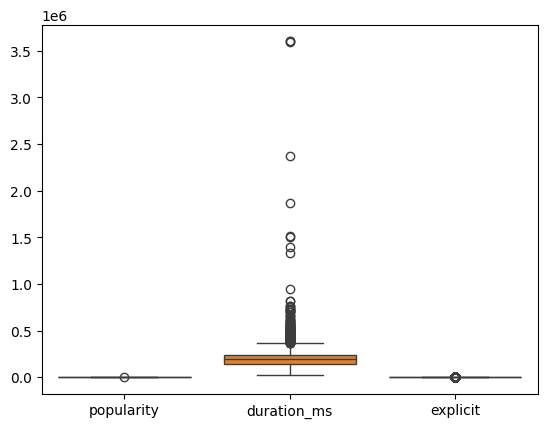

In [14]:
#Q6: Identify any potential outliers in a numerical column of your choice. Explain your approach.
sns.boxplot(data=data)
plt.show()

Here in duration we can see outliers because in some duration there are high. The technique used here is box plot so visually we can see the outliers more easily.

In [15]:
#Find the correlation between numerical columns and discuss any interesting relationships.




In [16]:
numerical_data = data.select_dtypes(include=['number'])
numerical_data.head()

,popularity,duration_ms
0,58,172199
1,57,172202
2,42,144786
3,46,116573
4,33,133922


In [19]:
correlation_matrix = numerical_data.corr()
correlation_matrix

,popularity,duration_ms
popularity,1.000000,0.023051
duration_ms,0.023051,1.000000


In [20]:
#Group the data by a categorical column and compute the aggregate statistics (e.g., mean, sum) for a numerical column.
data.groupby('genre')['popularity'].agg(['mean','median','std'])

,mean,median,std
genre,,,
acoustic,26.28,24.5,23.190463
afrobeat,27.00,20.5,26.390320
alt-rock,30.18,29.5,12.948390
alternative,26.72,25.5,12.409739
ambient,32.60,32.5,15.480073
...,...,...,...
trance,34.34,32.5,14.601663
trip-hop,23.00,27.0,15.472161
turkish,23.12,23.5,15.739772


In [21]:
#Based on your analysis, provide a brief summary of any insights or patterns you discovered in the dataset.

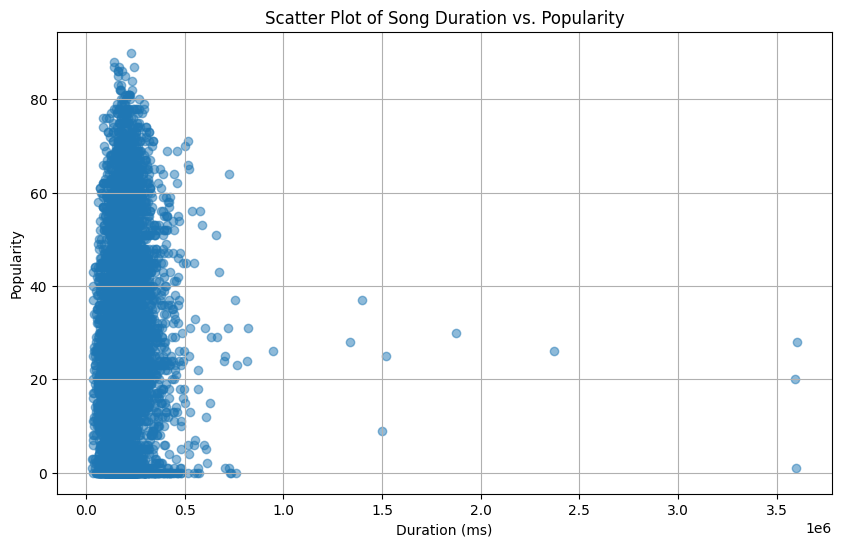

In [22]:
x = data['duration_ms']
y = data['popularity']


plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5)
plt.title('Scatter Plot of Song Duration vs. Popularity')
plt.xlabel('Duration (ms)')
plt.ylabel('Popularity')
plt.grid(True)
plt.show()

The graph shows a dense cluster of points around the lower duration end, particularly concentrated between 0 and approximately 0.5 million milliseconds. This suggests that most songs have a duration within this range. As the duration increases, there are fewer points, indicating that longer songs are less common.

In summary, shorter songs (up to approximately 8 minutes) are more commonly represented in this dataset than longer ones.